# Gradient Boosting Model: CatBoost

In [1]:
# Settings

import os
import json
import pandas as pd
import numpy as np
import torch
import optuna
import joblib
from pathlib import Path
from numpy import f2py
from copy import deepcopy
from catboost import CatBoostClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, fbeta_score, f1_score, recall_score, precision_score, precision_recall_curve, auc, average_precision_score
from src.utils.data_fetch import DataLoader
from src.utils.model_eval.evaluation import evaluate_predictions
from src.visualisations.viz_model import plot_confusion_matrix


SEED = 1234
TUNE = False
TUNE_PROB = False
TUNE_SAVE = True
TUNE_METRIC = 'prauc' # recall/auc/f1/f2/prauc
TUNE_OUTPUT = f'catboost_params_{TUNE_METRIC}.json'
TUNE_PROB_OUTPUT = f'catboost_prob_{TUNE_METRIC}.json'
MODEL_OUTPUT = f'catboost_model_{TUNE_METRIC}.json'
MODEL_SAVE = False
MODEL_LOAD = True
N_TRIALS = 150

D:\Projects\datasci_207_project\ds207_final_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load data
X_train, X_val, X_test, y_train, y_val, y_test = DataLoader().fetch_data(version='final_raw')

# Remove ID and drug (not grouped) columns
id_cols = [c for c in X_train.columns if 'encounter_id' in c or 'patient_nbr' in c]
drug_cols = [c for c in X_train.columns if 'prescript' in c and (('Up' in c) or ('Down' in c) or ('Steady' in c) or ('No' in c))]
drug_group_cols = [c for c in X_train.columns if 'prescript' in c and (('prescribed' in c) or ('change' in c))]
drop_cols = id_cols + drug_cols
X_train = X_train.drop(drop_cols, axis=1)
X_val = X_val.drop(drop_cols, axis=1)
X_test = X_test.drop(drop_cols, axis=1)

# Convert categorical column types
cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')
    X_val[col] = X_val[col].astype('category')
    X_test[col] = X_test[col].astype('category')

# Convert y data types
df_y_train = y_train.copy()
df_y_val = y_val.copy()
df_y_test = y_test.copy()
y_train = y_train.values.ravel()
y_val = y_val.values.ravel()
y_test = y_test.values.ravel()

# Modify special characters in column names for xgboost tuning
cols_update = [c.replace('[', '(').replace(')', ')').replace('<', 'lt').replace('>', 'gt') for c in X_train.columns]
X_train.columns = cols_update
X_val.columns = cols_update
X_test.columns = cols_update

cat_features = X_train.select_dtypes(include=['category']).columns.tolist()

Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/X_test.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_train_mini.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_val.csv 
Data loaded from path:  https://raw.githubusercontent.com/wip-0/ds207_final_project/refs/heads/main/data/final_processed/base_kf/raw/y_test.csv 
Data imported succesfully from paths


### Hyperparameter tuning

In [3]:
# Define objective function
fixed_params = {
    'loss_function'   : 'Logloss',
    'eval_metric'     : 'Logloss',
    'task_type'       : 'GPU',
    'devices'         : '0',
    'random_seed'     : SEED,
    'verbose'         : False,
}

def objective(trial):
    """
    Hyperparameter tuning objective function.

    Args:
        trial: Tuning hyperparameter trial

    Returns:
        Assessment score
    """
    params                 = {
        'bootstrap_type'  : trial.suggest_categorical('bootstrap_type', ['Bayesian', 'Bernoulli', 'MVS']),
        'border_count'    : trial.suggest_categorical('border_count', [32, 64, 128]),
        'iterations'      : 3000,
        'depth'           : trial.suggest_int('depth'             , 4    , 8),
        'learning_rate'   : trial.suggest_float('learning_rate'   , 0.005, 0.2 , log = True),
        'random_strength' : trial.suggest_float('random_strength' , 0.001, 10  , log = True),
        'l2_leaf_reg'     : trial.suggest_float('l2_leaf_reg'     , 0.001, 10  , log = True),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 0.8  , 1.2),
    }
    params.update(fixed_params)

    if params['bootstrap_type'] == 'Bayesian':
        params['bagging_temperature'] = trial.suggest_float('bagging_temperature', 0.0, 5.0)
    else:
        params['subsample'] = trial.suggest_float('subsample', 0.2, 1.0)

    # Fit the model
    model = CatBoostClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train,
              y_train,
              cat_features=cat_features,
              eval_set=(X_val, y_val),
              use_best_model=True,
              verbose=False,
              )

    trial.set_user_attr('best_iteration', model.get_best_iteration())

    y_prob_val = model.predict_proba(X_val)[:, 1]
    y_pred_train = model.predict(X_train)
    y_pred_val = model.predict(X_val)

    acc_train = accuracy_score(y_train, y_pred_train)
    acc_val = accuracy_score(y_val, y_pred_val)
    if acc_train - acc_val > 0.10:  # >10% gap suggests overfitting
        print(f"Warning: Possible overfitting")
        return 0

    recall = recall_score(y_val, y_pred_val)
    precision = precision_score(y_val, y_pred_val)
    accuracy = accuracy_score(y_val, y_pred_val)
    roc_auc = roc_auc_score(y_val, y_prob_val)

    match TUNE_METRIC:
        case 'recall':
            score = recall
        case 'f1':
            score = f1_score(y_val, y_pred_val, average='macro')
        case 'f2':
            score = fbeta_score(y_val, y_pred_val, beta=2, average='macro')
        case 'auc':
            score = roc_auc_score(y_val, y_prob_val)
        case 'prauc':
            # p, r, th = precision_recall_curve(y_val, y_prob_val)
            # score = auc(r, p)
            score = average_precision_score(y_val, y_prob_val)

    trial_params = trial.params
    trial_params['iterations'] = model.get_best_iteration()
    print(f'Trial: {trial.number} - Score: {score} | Recall: {recall} | Precision: {precision} | Accuracy: {accuracy} | ROC-AUC: {roc_auc} | Parameters: {trial_params}')

    return score


def log_callback(study, trial):
    """
    Optuner logging callback.
    """
    print(f'Best trial: {study.best_trial.number} | Score: {study.best_value}\n')

### Probability threshold tuning

In [4]:
# Perform tuning and save the best parameters
if TUNE:
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=N_TRIALS, n_jobs=1, callbacks=[log_callback])
    best_params = study.best_params
    best_params['iterations'] = study.best_trial.user_attrs.get('best_iteration') + 1
    print('Best Trial:', study.best_trial.number)
    print('Best Value:', study.best_value)
    print('Best Parameters:', best_params)

    if TUNE_SAVE:
        # Save output
        print('Parameters saved to:', TUNE_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'w') as f:
            json.dump(best_params, f)

In [5]:
def tune_prob_th(best_params, min_recall=0.8):
    """
    Probability threshold tuning by maximizing precision for a given recall threshold.
    """
    final_params = deepcopy(fixed_params)
    final_params.update(best_params)
    print('Final params:', final_params)

    # Fit the model
    model = CatBoostClassifier(**final_params)
    model.fit(X_train,
              y_train,
              cat_features=cat_features,
              use_best_model=False,
              verbose=False,
              )
    y_prob = model.predict_proba(X_val)[:, 1]
    precision, recall, th = precision_recall_curve(y_val, y_prob)

    # remove extra endpoint w/o th
    precision = precision[:-1]
    recall = recall[:-1]

    # Get thresholds above min recall
    idx_r = np.flatnonzero(recall > min_recall)
    max_p = np.max(precision[idx_r])
    idx_best_th = idx_r[np.isclose(precision[idx_r], max_p, rtol=1e-10, atol=1e-10)]
    best_th = th[idx_best_th[np.argmax(th[idx_best_th])]]

    return float(best_th)

# Tune probability threshold
if TUNE_PROB:

    with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
        best_params = json.load(f)

    best_th = tune_prob_th(best_params)

    if TUNE_SAVE:
        # Save output
        print('Parameters saved to:', TUNE_PROB_OUTPUT)
        with open(os.path.join(os.getcwd(), TUNE_PROB_OUTPUT), 'w') as f:
            json.dump({'best_th': best_th}, f)

### Model training with the best parameters

In [6]:
# Fit model
if not MODEL_LOAD:

    # Load parameters
    with open(os.path.join(os.getcwd(), TUNE_OUTPUT), 'r') as f:
        best_params = json.load(f)

    final_params = deepcopy(fixed_params)
    final_params.update(best_params)
    print('Final params:', final_params)

    # Fit the model
    model = CatBoostClassifier(**final_params)
    model.fit(X_train,
              y_train,
              cat_features=cat_features,
              use_best_model=False,
              verbose=False,
              )

    # Save model
    if MODEL_SAVE:
        joblib.dump(model, os.path.join(os.getcwd(), MODEL_OUTPUT))

# Load model
else:
    model = joblib.load(os.path.join(os.getcwd(), MODEL_OUTPUT))

### Performance assessment

### Train results ###
              precision    recall  f1-score   support

           0       0.76      0.46      0.57     31515
           1       0.58      0.83      0.68     28090

    accuracy                           0.64     59605
   macro avg       0.67      0.65      0.63     59605
weighted avg       0.67      0.64      0.63     59605

f1: 0.6840853026609642
recall: 0.8342114631541474
precision: 0.5797520967861649
accuracy: 0.6368928781142522




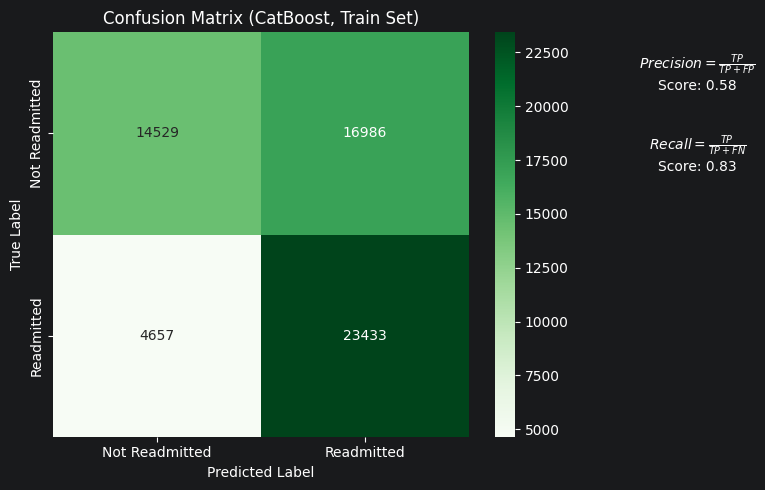

### Validation results ###
              precision    recall  f1-score   support

           0       0.71      0.45      0.55     10506
           1       0.56      0.80      0.66      9363

    accuracy                           0.61     19869
   macro avg       0.64      0.62      0.60     19869
weighted avg       0.64      0.61      0.60     19869

f1: 0.6602583888178492
recall: 0.7996368685250453
precision: 0.5622559327125263
accuracy: 0.612209975338467




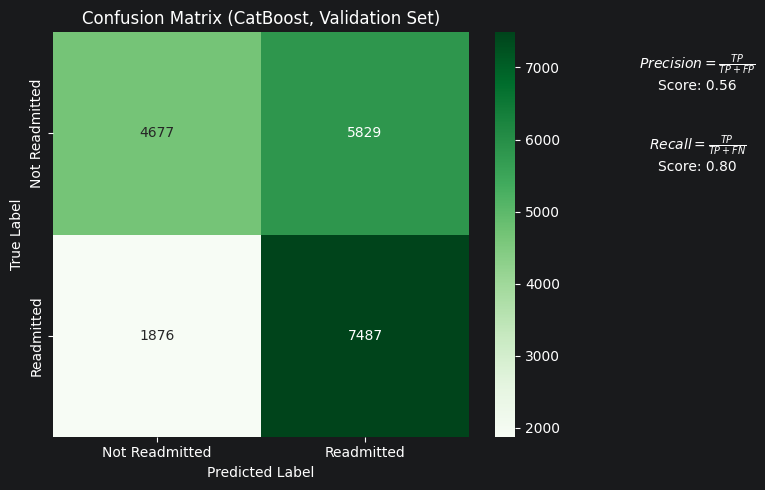

### Test results ###
              precision    recall  f1-score   support

           0       0.71      0.44      0.55     10506
           1       0.56      0.80      0.66      9363

    accuracy                           0.61     19869
   macro avg       0.64      0.62      0.60     19869
weighted avg       0.64      0.61      0.60     19869

f1: 0.6595547718756888
recall: 0.7989960482751255
precision: 0.5615523194715508
accuracy: 0.6113040414716392




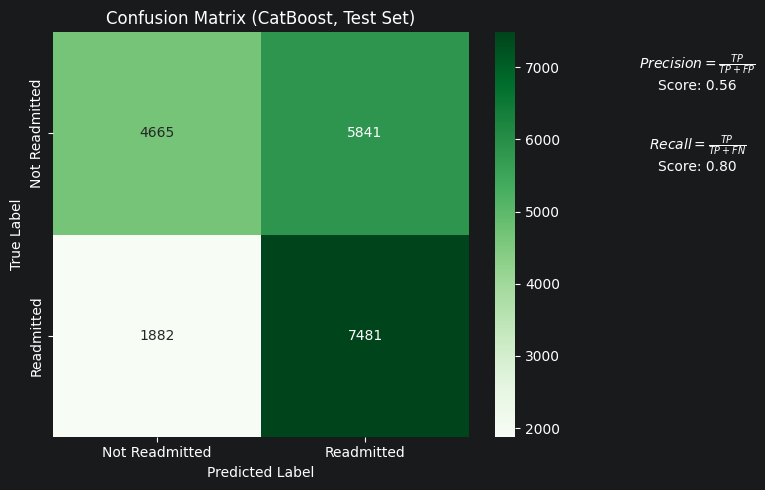

In [7]:
# Load prob threshold
with open(os.path.join(os.getcwd(), TUNE_PROB_OUTPUT), 'r') as f:
    best_th = json.load(f)['best_th']

# Predict outcomes
y_pred_train = (model.predict_proba(X_train)[:, 1] >= best_th) * 1
y_pred_val = (model.predict_proba(X_val)[:, 1] >= best_th) * 1
y_pred_test = (model.predict_proba(X_test)[:, 1] >= best_th) * 1

# Train results
print('### Train results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=df_y_train,
                     predictions=y_pred_train,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_train = plot_confusion_matrix(df_y_train,
                                         y_pred_train,
                                         class_names=['Not Readmitted', 'Readmitted'],
                                         fig_size=(8,5),
                                         title='Confusion Matrix (CatBoost, Train Set)',
                                         colour_map='Greens'
                                         )

# Test results
print('### Validation results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=df_y_val,
                     predictions=y_pred_val,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_val = plot_confusion_matrix(df_y_val,
                                       y_pred_val,
                                       class_names=['Not Readmitted', 'Readmitted'],
                                       fig_size=(8,5),
                                       title='Confusion Matrix (CatBoost, Validation Set)',
                                       colour_map='Greens'
                                       )

# Test results
print('### Test results ###')
recall, precision, f1, acc,  cl_report = \
evaluate_predictions(true_values=df_y_test,
                     predictions=y_pred_test,
                     print_class_report=True)
print('f1:', f1)
print('recall:', recall)
print('precision:', precision)
print('accuracy:', acc)
print('\n')
results_cm_test = plot_confusion_matrix(df_y_test,
                                        y_pred_test,
                                        class_names=['Not Readmitted', 'Readmitted'],
                                        fig_size=(8,5),
                                        title='Confusion Matrix (CatBoost, Test Set)',
                                        colour_map='Greens'
                                        )

<Axes: title={'center': 'Feature Importance'}, xlabel='feature'>

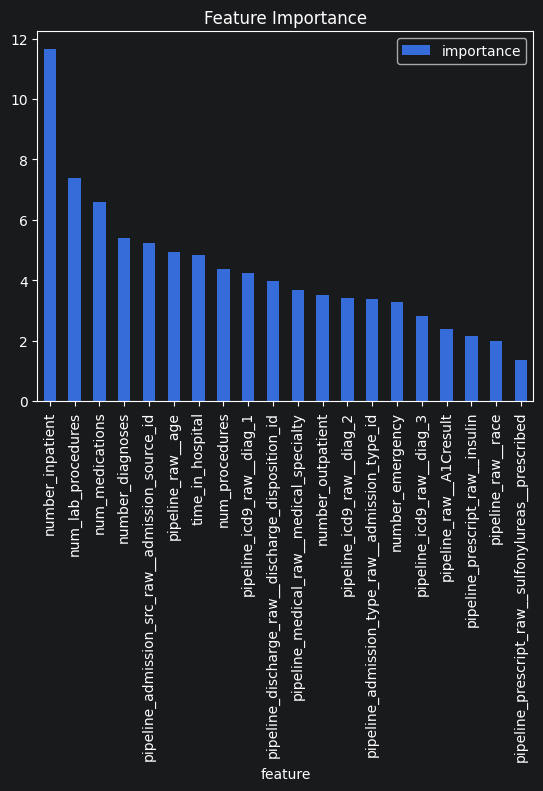

In [11]:
dict_imp = {
    'feature': model.feature_names_,
    'importance': model.get_feature_importance(),
}
df_imp = pd.DataFrame(dict_imp)
df_imp.sort_values(by=['importance'], ascending=False, inplace=True)
# df_imp['feature'] = [c.split('__')[-1] for c in df_imp['feature']]

# Plot feature importance
df_imp.head(20).plot(kind='bar',
                     title='Feature Importance',
                     x='feature',
                     y='importance',
                     )